# Random Parameter-Shift Hard-Constraint QFM, Cheb-QPINN, and $B_2$-QPINN
This notebook compares the three hard-constraint quantum PINN variants we currently care about:
- **QFM**: the ordinary unsymmetrized quantum Fourier model.
- **Cheb-QPINN**: the same unsymmetrized circuit evaluated on $z=\arccos(x)$.
- **$B_2$-QPINN**: the raw-input circuit averaged over the two-dimensional hyperoctahedral group.
All three models use the same hard Dirichlet boundary ansatz, the same PDE, and the same random parameter-shift loss-gradient estimator. Soft-boundary variants are intentionally omitted here.
## PDE
The benchmark is the two-dimensional screened Poisson problem
$$
\Omega=(-1,1)^2,
\qquad
\partial\Omega=\{x\in[-1,1]^2:\ |x_1|=1\ \text{or}\ |x_2|=1\}.
$$
$$
(-\Delta+\lambda)u(x)=f(x),\qquad x\in\Omega,
$$
with homogeneous Dirichlet boundary condition
$$
u(x)=0,
\qquad x\in\partial\Omega.
$$
In this notebook,
$$
\lambda=1,
$$
and
$$
f(x_1,x_2)
=
\cos\frac{\pi x_1}{2}\cos\frac{\pi x_2}{2}
+0.3\cos\frac{\pi x_1}{2}\cos\frac{3\pi x_2}{2}
+0.3\cos\frac{3\pi x_1}{2}\cos\frac{\pi x_2}{2}.
$$
Equivalently,
$$
f(x)=\sum_{m\in\{(1,1),(1,3),(3,1)\}} c_m
\cos\frac{m_1\pi x_1}{2}
\cos\frac{m_2\pi x_2}{2},
$$
where
$$
c_{(1,1)}=1,
\qquad
c_{(1,3)}=c_{(3,1)}=0.3.
$$
The analytical solution used for evaluation is
$$
u^\star(x)
=
\sum_m
\frac{c_m}{\lambda + (m_1\pi/2)^2 + (m_2\pi/2)^2}
\cos\frac{m_1\pi x_1}{2}
\cos\frac{m_2\pi x_2}{2}.
$$
## Hard-Constraint QPINN Ansatz
The circuit expectation is
$$
v_\theta(x)
=
\frac{1}{|G|}
\sum_{g\in G}
\left\langle 0\right|
U_\theta(gx)^\dagger O U_\theta(gx)
\left|0\right\rangle.
$$
For the ordinary QFM and Cheb-QPINN,
$$
G=\{e\}.
$$
For the $B_2$-QPINN,
$$
G=B_2,
$$
where $B_2$ contains all coordinate permutations and sign flips in two dimensions. The ordinary QFM and $B_2$-QPINN use raw input $z=x$, while Cheb-QPINN uses
$$
z_d=\arccos(x_d).
$$
For Cheb-QPINN, the residual applies the corresponding chain rule for $\partial_{x_d}v$ and $\partial_{x_d}^2v$.
The circuit is a data-reuploading StronglyEntangling-style circuit. Each upload block contains trainable rotations followed by data encoding gates
$$
R_X(\beta_j x_d)
=
\exp\left(-i\beta_j x_d X/2\right),
\qquad
\beta_j=3^j.
$$
The hard boundary condition is built into the ansatz:
$$
u_\theta(x)=B(x)v_\theta(x),
\qquad
B(x)=\prod_{d=1}^2 \cos\frac{\pi x_d}{2}.
$$
Therefore $u_\theta(x)=0$ on $\partial\Omega$ by construction.
## Loss
The PDE residual is
$$
r_\theta(x)
=
(-\Delta+\lambda)u_\theta(x)-f(x).
$$
Because the boundary condition is hard constrained, the training objective is only the interior residual loss:
$$
\mathcal L(\theta)
=
\frac{1}{N_\Omega}\sum_{i=1}^{N_\Omega} r_\theta(x_i)^2.
$$
For
$$
u_\theta(x)=B(x)v_\theta(x),
$$
we use
$$
\Delta(Bv)
=
\sum_{d=1}^2
\left(
\partial_{x_d}^2 B \, v
+2\partial_{x_d}B\,\partial_{x_d}v
+B\,\partial_{x_d}^2 v
\right).
$$
Thus the residual is a linear combination of
$$
v,
\qquad
\partial_{x_d}v,
\qquad
\partial_{x_d}^2v.
$$
## Parameter-Shift Expansion For Spatial Derivatives
Let $q_\theta(gx)$ denote one group-transformed circuit expectation. Suppose encoding gate $j$ has angle
$$
\alpha_j(gx)=\beta_j(gx)_{d_j}.
$$
For derivative direction $d$, define
$$
a_{j,d}^{(g)}=
\beta_j\frac{\partial (gx)_{d_j}}{\partial x_d}.
$$
The first derivative is exactly
$$
\partial_{x_d}v_\theta(x)
=
\frac{1}{|G|}
\sum_{g\in G}
\sum_j
\frac{a_{j,d}^{(g)}}{2}
\left[
q_\theta^{(g,j,+)}(x)
-
q_\theta^{(g,j,-)}(x)
\right],
$$
where $q_\theta^{(g,j,+)}$ means the $j$-th data-encoding gate is shifted by $+\pi/2$, and $q_\theta^{(g,j,-)}$ means it is shifted by $-\pi/2$.
The second derivative is also an exact finite sum:
$$
\partial_{x_d}^2v_\theta(x)
=
\frac{1}{|G|}
\sum_{g\in G}
\sum_{j,k}
\frac{a_{j,d}^{(g)}a_{k,d}^{(g)}}{4}
\sum_{\sigma,\tau\in\{-1,+1\}}
\sigma\tau\,
q_\theta^{(g,j,\sigma,k,\tau)}(x).
$$
The notebook keeps these derivative expansions explicit instead of using classical automatic differentiation.
## Loss Gradient
For one trainable circuit parameter $\theta_\ell$,
$$
\frac{\partial\mathcal L}{\partial\theta_\ell}
=
\frac{2}{N_\Omega}
\sum_{i=1}^{N_\Omega}
r_\theta(x_i)
\frac{\partial r_\theta(x_i)}{\partial\theta_\ell}.
$$
The residual derivative is formed by applying $\partial_{\theta_\ell}$ to the same linear combination of
$$
v,
\qquad
\partial_{x_d}v,
\qquad
\partial_{x_d}^2v.
$$
Each trainable rotation parameter has the two-term parameter-shift rule
$$
\partial_{\theta_\ell}q_\theta(x)
=
\frac{1}{2}
\left[
q_{\theta+\frac{\pi}{2}e_\ell}(x)
-
q_{\theta-\frac{\pi}{2}e_\ell}(x)
\right].
$$
Combining this with the spatial derivative expansion gives a large signed sum:
$$
\frac{\partial r_\theta(x_i)}{\partial\theta_\ell}
=
\sum_{t\in\mathcal T_i}
w_{i,t}
\frac{1}{2}
\left[
q_{\theta+\frac{\pi}{2}e_\ell}^{(t)}(x_i)
-
q_{\theta-\frac{\pi}{2}e_\ell}^{(t)}(x_i)
\right].
$$
Here $t$ indexes all value, first-derivative, and second-derivative shift terms needed by the residual, and $w_{i,t}$ includes the PDE coefficient, hard-boundary envelope coefficient, group-average factor, and data-shift signs.
The deterministic gradient would enumerate all terms $t$. The random version samples shift terms uniformly with replacement. If
$$
S_\ell \sim \mathrm{Unif}(\mathcal T_\ell),
$$
then
$$
\widehat{
\frac{\partial r_\theta(x_i)}{\partial\theta_\ell}
}
=
|\mathcal T_\ell|\, w_{i,S_\ell}\,
\frac{1}{2}
\left[
q_{\theta+\frac{\pi}{2}e_\ell}^{(S_\ell)}(x_i)
-
q_{\theta-\frac{\pi}{2}e_\ell}^{(S_\ell)}(x_i)
\right]
$$
is unbiased:
$$
\mathbb E\left[
\widehat{
\frac{\partial r_\theta(x_i)}{\partial\theta_\ell}
}
\right]
=
\frac{\partial r_\theta(x_i)}{\partial\theta_\ell}.
$$
In the run cell, `MC_SAMPLES_PER_PARAMETER` is the Monte Carlo sample number. Each trainable parameter receives that many draws from the full residual-gradient term pool. The sampled sum is rescaled by the pool size, so the estimator is unbiased. `PARAMETERS_PER_STEP` can optionally sample only a subset of trainable parameters per training step; that subset estimator is also rescaled so that its expectation is still the full loss gradient.
## Optimizer Choices
The notebook supports either Adam or plain gradient descent. Adam is the default, while gradient descent uses
$$
\theta_{t+1}=\theta_t-\eta_t\widehat{\nabla_\theta\mathcal L(\theta_t)}.
$$
Both use the same random parameter-shift gradient estimator.


## CUDA Random Parameter-Shift Implementation


In [ ]:
from __future__ import annotations
"""Random parameter-shift QPINN for the B2 screened-Poisson benchmark.
This notebook mirrors the PDE, circuit ansatz, source term, hard boundary
envelope, and hyperoctahedral averaging used by
QPINN_hyperoctahedral_chebyshev_autograd.ipynb.
The training path intentionally avoids classical automatic differentiation:
spatial derivatives are expanded into data-encoding parameter-shift terms, and
loss gradients are estimated by randomly sampling trainable-parameter shift
terms from that expansion. PyTorch is used as a CUDA tensor runtime plus a
manual Adam or gradient-descent optimizer.
"""
import argparse
import math
import random
import sys
from collections import defaultdict
from dataclasses import dataclass
from itertools import permutations, product
from pathlib import Path
from typing import Literal
import numpy as np
import torch
Quantity = Literal["value", "d1", "d2"]
@dataclass(frozen=True)
class QPinnConfig:
    dim: int = 2
    n_qubits: int = 2
    n_upload_layers: int = 2
    strong_layers_per_block: int = 2
    exp_base: float = 3.0
    encoding_scale: float = 1.0
    output_scale: float = 1.0
    diff_generator_per_layer: bool = False
    acos_eps: float = 1.0e-6
    screening_lambda: float = 1.0
    source_mode_coefficients: tuple[tuple[tuple[int, int], float], ...] = (
        ((1, 1), 1.0),
        ((1, 3), 0.3),
        ((3, 1), 0.3),
    )
    training_steps: int = 10
    n_runs: int = 1
    interior_batch: int = 50
    boundary_batch: int = 50
    lr: float = 1.0e-1
    lr_decay: float = 0.99
    lr_min: float = 1.0e-4
    optimizer: Literal["adam", "gd"] = "gd"
    interior_margin: float = 0.94
    grad_clip: float = 5.0
    init_scale: float = 0.2
    shift_samples: int = 1
    parameters_per_step: int = 0
    eval_grid_n: int = 41
    seed: int = 71
    dtype: torch.dtype = torch.float32
@dataclass(frozen=True)
class ModelSpec:
    label: str
    slug: str
    group: Literal["none", "hyperoctahedral"]
    input_map: Literal["raw", "chebyshev"]
@dataclass(frozen=True)
class DataShift:
    upload: int
    wire: int
    sign: int
@dataclass(frozen=True)
class ParamShift:
    flat_index: int
    sign: int
@dataclass(frozen=True)
class WeightedTerm:
    group_coeffs: torch.Tensor
    data_shifts: tuple[DataShift, ...]
    param_shift: ParamShift | None = None
@dataclass
class GroupBatch:
    transformed_z: torch.Tensor
    transform: torch.Tensor
    group_size: int
    batch_size: int
@dataclass
class ShiftRuleModel:
    spec: ModelSpec
    hard_boundary: bool
    weights: torch.Tensor
    def clone(self) -> "ShiftRuleModel":
        return ShiftRuleModel(self.spec, self.hard_boundary, self.weights.clone())
@dataclass
class AdamState:
    m: torch.Tensor
    v: torch.Tensor
    step: int = 0
MODEL_SPECS: tuple[ModelSpec, ...] = (
    ModelSpec("Ordinary QFM", "ordinary", "none", "raw"),
    ModelSpec("Cheb-QFM", "cheb", "none", "chebyshev"),
    ModelSpec("$B_2$-QCM", "b2", "hyperoctahedral", "raw"),
)
DISPLAY_LABELS = {
    "Ordinary QFM": "Fourier-QPINN",
    "Cheb-QFM": "Chebyshev-QPINN",
    "$B_2$-QCM": "$B_2$-QPINN",
}
CONSTRAINT_SETUPS = {
    "hard": {"label": "Hard constraint", "hard_boundary": True, "boundary_weight": 0.0},
}
LOSS_COLORS = {
    "Ordinary QFM": "#1f77b4",
    "Cheb-QFM": "#7b2cbf",
    "$B_2$-QCM": "#d62728",
}
_CNOT_GATHER_CACHE: dict[tuple[int, int, int, str], torch.Tensor] = {}
def select_device(allow_cpu: bool) -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if allow_cpu:
        return torch.device("cpu")
    raise RuntimeError(
        "CUDA is required by default for this random-shift QPINN. "
        "Pass --allow-cpu only for a small syntax/debug run."
    )
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
def as_1d(theta: torch.Tensor) -> torch.Tensor:
    return theta.reshape(1) if theta.ndim == 0 else theta
def complex_pair(real: torch.Tensor, imag: torch.Tensor, dtype: torch.dtype) -> torch.Tensor:
    return torch.stack([real.to(dtype), imag.to(dtype)], dim=-1)
def scale_complex(scale: torch.Tensor, value: torch.Tensor) -> torch.Tensor:
    return scale[..., None] * value
def multiply_complex(left: torch.Tensor, right: torch.Tensor) -> torch.Tensor:
    real = left[..., 0] * right[..., 0] - left[..., 1] * right[..., 1]
    imag = left[..., 0] * right[..., 1] + left[..., 1] * right[..., 0]
    return torch.stack([real, imag], dim=-1)
def gate_from_entries(
    entry00: torch.Tensor,
    entry01: torch.Tensor,
    entry10: torch.Tensor,
    entry11: torch.Tensor,
) -> torch.Tensor:
    row0 = torch.stack([entry00, entry01], dim=1)
    row1 = torch.stack([entry10, entry11], dim=1)
    return torch.stack([row0, row1], dim=1)
def complex_exp(angle: torch.Tensor, dtype: torch.dtype) -> torch.Tensor:
    return complex_pair(torch.cos(angle), torch.sin(angle), dtype)
def rx_matrix(theta: torch.Tensor, dtype: torch.dtype) -> torch.Tensor:
    theta = as_1d(theta)
    half = 0.5 * theta
    c = torch.cos(half)
    s = torch.sin(half)
    z = torch.zeros_like(c)
    return gate_from_entries(
        complex_pair(c, z, dtype),
        complex_pair(z, -s, dtype),
        complex_pair(z, -s, dtype),
        complex_pair(c, z, dtype),
    )
def rot_matrix(phi: torch.Tensor, theta: torch.Tensor, omega: torch.Tensor, dtype: torch.dtype) -> torch.Tensor:
    phi = as_1d(phi)
    theta = as_1d(theta)
    omega = as_1d(omega)
    half_theta = 0.5 * theta
    c = torch.cos(half_theta)
    s = torch.sin(half_theta)
    half_sum = 0.5 * (phi + omega)
    half_diff = 0.5 * (phi - omega)
    return gate_from_entries(
        scale_complex(c, complex_exp(-half_sum, dtype)),
        scale_complex(-s, complex_exp(half_diff, dtype)),
        scale_complex(s, complex_exp(-half_diff, dtype)),
        scale_complex(c, complex_exp(half_sum, dtype)),
    )
def apply_single_qubit_gate(state: torch.Tensor, gate: torch.Tensor, wire: int, cfg: QPinnConfig) -> torch.Tensor:
    batch = state.shape[0]
    if gate.shape[0] == 1 and batch != 1:
        gate = gate.expand(batch, -1, -1, -1)
    tensor = state.reshape(batch, *([2] * cfg.n_qubits), 2)
    axis = wire + 1
    tensor = tensor.movedim(axis, -2)
    broadcast_shape = (batch,) + (1,) * (tensor.ndim - 3) + (2,)
    g00 = gate[:, 0, 0, :].reshape(broadcast_shape)
    g01 = gate[:, 0, 1, :].reshape(broadcast_shape)
    g10 = gate[:, 1, 0, :].reshape(broadcast_shape)
    g11 = gate[:, 1, 1, :].reshape(broadcast_shape)
    input0 = tensor[..., 0, :]
    input1 = tensor[..., 1, :]
    output0 = multiply_complex(g00, input0) + multiply_complex(g01, input1)
    output1 = multiply_complex(g10, input0) + multiply_complex(g11, input1)
    updated = torch.stack([output0, output1], dim=-2)
    updated = updated.movedim(-2, axis)
    return updated.reshape(batch, 2**cfg.n_qubits, 2)
def cnot_gather_index(n_qubits: int, control: int, target: int, device: torch.device) -> torch.Tensor:
    key = (n_qubits, control, target, str(device))
    if key in _CNOT_GATHER_CACHE:
        return _CNOT_GATHER_CACHE[key]
    gather = [0] * (2**n_qubits)
    for input_index in range(2**n_qubits):
        bits = [(input_index >> (n_qubits - 1 - q)) & 1 for q in range(n_qubits)]
        output_bits = bits[:]
        if bits[control] == 1:
            output_bits[target] ^= 1
        output_index = 0
        for bit in output_bits:
            output_index = (output_index << 1) | bit
        gather[output_index] = input_index
    tensor = torch.tensor(gather, dtype=torch.long, device=device)
    _CNOT_GATHER_CACHE[key] = tensor
    return tensor
def apply_cnot(state: torch.Tensor, control: int, target: int, cfg: QPinnConfig) -> torch.Tensor:
    gather = cnot_gather_index(cfg.n_qubits, control, target, state.device)
    return state[:, gather, :]
def initial_state(batch: int, cfg: QPinnConfig, device: torch.device) -> torch.Tensor:
    state = torch.zeros(batch, 2**cfg.n_qubits, 2, dtype=cfg.dtype, device=device)
    state[:, 0, 0] = 1.0
    return state
def local_observable_values(cfg: QPinnConfig, device: torch.device) -> torch.Tensor:
    values = []
    for basis_index in range(2**cfg.n_qubits):
        bits = [(basis_index >> (cfg.n_qubits - 1 - q)) & 1 for q in range(cfg.n_qubits)]
        values.append(sum(1.0 for bit in bits if bit == 0) / cfg.n_qubits)
    return torch.tensor(values, dtype=cfg.dtype, device=device)
def encoding_beta(upload: int, wire: int, cfg: QPinnConfig) -> float:
    exponent = upload * cfg.n_qubits + wire if cfg.diff_generator_per_layer else wire
    return cfg.exp_base**exponent
def data_shift_angle(data_shifts: tuple[DataShift, ...], upload: int, wire: int) -> float:
    total = 0
    for shift in data_shifts:
        if shift.upload == upload and shift.wire == wire:
            total += shift.sign
    return 0.5 * math.pi * total
def unravel_param_index(flat_index: int, cfg: QPinnConfig) -> tuple[int, int, int, int]:
    component = flat_index % 3
    flat_index //= 3
    wire = flat_index % cfg.n_qubits
    flat_index //= cfg.n_qubits
    sublayer = flat_index % cfg.strong_layers_per_block
    flat_index //= cfg.strong_layers_per_block
    block = flat_index
    return block, sublayer, wire, component
def shifted_rot_angles(
    weights: torch.Tensor,
    block: int,
    sublayer: int,
    wire: int,
    param_shift: ParamShift | None,
    cfg: QPinnConfig,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    angles = weights[block, sublayer, wire]
    phi, theta, omega = angles[0], angles[1], angles[2]
    if param_shift is None:
        return phi, theta, omega
    shifted_block, shifted_sublayer, shifted_wire, component = unravel_param_index(param_shift.flat_index, cfg)
    if (block, sublayer, wire) != (shifted_block, shifted_sublayer, shifted_wire):
        return phi, theta, omega
    shift_value = 0.5 * math.pi * param_shift.sign
    if component == 0:
        phi = phi + shift_value
    elif component == 1:
        theta = theta + shift_value
    else:
        omega = omega + shift_value
    return phi, theta, omega
def apply_strongly_entangling_block(
    state: torch.Tensor,
    weights: torch.Tensor,
    block: int,
    param_shift: ParamShift | None,
    cfg: QPinnConfig,
) -> torch.Tensor:
    for sublayer in range(cfg.strong_layers_per_block):
        for wire in range(cfg.n_qubits):
            phi, theta, omega = shifted_rot_angles(weights, block, sublayer, wire, param_shift, cfg)
            state = apply_single_qubit_gate(state, rot_matrix(phi, theta, omega, cfg.dtype), wire, cfg)
        if cfg.n_qubits > 1:
            cnot_range = (sublayer % (cfg.n_qubits - 1)) + 1
            for control in range(cfg.n_qubits):
                target = (control + cnot_range) % cfg.n_qubits
                state = apply_cnot(state, control, target, cfg)
    return state
def base_circuit(
    transformed_z: torch.Tensor,
    weights: torch.Tensor,
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
    data_shifts: tuple[DataShift, ...] = (),
    param_shift: ParamShift | None = None,
) -> torch.Tensor:
    state = initial_state(transformed_z.shape[0], cfg, transformed_z.device)
    for upload in range(cfg.n_upload_layers):
        state = apply_strongly_entangling_block(state, weights, upload, param_shift, cfg)
        for wire in range(cfg.n_qubits):
            coordinate = wire % cfg.dim
            beta = encoding_beta(upload, wire, cfg)
            angle = cfg.encoding_scale * beta * transformed_z[:, coordinate]
            shift_angle = data_shift_angle(data_shifts, upload, wire)
            if shift_angle:
                angle = angle + shift_angle
            state = apply_single_qubit_gate(state, rx_matrix(angle, cfg.dtype), wire, cfg)
    state = apply_strongly_entangling_block(state, weights, cfg.n_upload_layers, param_shift, cfg)
    probabilities = torch.sum(state**2, dim=-1)
    return cfg.output_scale * (probabilities @ observable_values)
def map_circuit_input_with_derivatives(
    x: torch.Tensor,
    input_map: Literal["raw", "chebyshev"],
    cfg: QPinnConfig,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if input_map == "raw":
        z = x
        z_prime = torch.ones_like(x)
        z_second = torch.zeros_like(x)
        return z, z_prime, z_second
    if input_map == "chebyshev":
        clamped = torch.clamp(x, -1.0 + cfg.acos_eps, 1.0 - cfg.acos_eps)
        one_minus_x2 = torch.clamp(1.0 - clamped**2, min=cfg.acos_eps)
        z = torch.acos(clamped)
        z_prime = -torch.rsqrt(one_minus_x2)
        z_second = -clamped * torch.pow(one_minus_x2, -1.5)
        return z, z_prime, z_second
    raise ValueError(f"Unknown input_map: {input_map}")
def boundary_envelope_derivatives(x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    half_pi = 0.5 * math.pi
    cos_values = torch.cos(half_pi * x)
    sin_values = torch.sin(half_pi * x)
    envelope = torch.prod(cos_values, dim=1)
    first = torch.empty_like(x)
    for dim in range(x.shape[1]):
        factors = cos_values.clone()
        factors[:, dim] = -half_pi * sin_values[:, dim]
        first[:, dim] = torch.prod(factors, dim=1)
    second = -(half_pi**2) * envelope[:, None].expand_as(x)
    return envelope, first, second
def phi_mode(x: torch.Tensor, mode: int) -> torch.Tensor:
    return torch.cos(0.5 * mode * math.pi * x)
def source_term(x: torch.Tensor, cfg: QPinnConfig) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in cfg.source_mode_coefficients:
        value = value + coefficient * phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2)
    return value
def analytical_solution(x: torch.Tensor, cfg: QPinnConfig) -> torch.Tensor:
    value = torch.zeros(x.shape[0], dtype=x.dtype, device=x.device)
    for (m1, m2), coefficient in cfg.source_mode_coefficients:
        eigenvalue = (0.5 * math.pi * m1) ** 2 + (0.5 * math.pi * m2) ** 2
        mode_value = phi_mode(x[:, 0], m1) * phi_mode(x[:, 1], m2)
        value = value + coefficient * mode_value / (cfg.screening_lambda + eigenvalue)
    return value
def transform_batch(z: torch.Tensor, group: Literal["none", "hyperoctahedral"], cfg: QPinnConfig) -> GroupBatch:
    device = z.device
    dtype = z.dtype
    if group == "none":
        transform = torch.eye(cfg.dim, dtype=dtype, device=device).reshape(1, cfg.dim, cfg.dim)
        return GroupBatch(z, transform, 1, z.shape[0])
    if group == "hyperoctahedral":
        signs = torch.tensor(list(product([-1.0, 1.0], repeat=cfg.dim)), dtype=dtype, device=device)
        perms = list(permutations(range(cfg.dim)))
        transformed_chunks = []
        transform_chunks = []
        for perm in perms:
            permuted = z[:, list(perm)]
            for sign in signs:
                transformed_chunks.append(permuted * sign)
                matrix = torch.zeros(cfg.dim, cfg.dim, dtype=dtype, device=device)
                for row, source_dim in enumerate(perm):
                    matrix[row, source_dim] = sign[row]
                transform_chunks.append(matrix)
        transformed_z = torch.cat(transformed_chunks, dim=0)
        transform = torch.stack(transform_chunks, dim=0)
        return GroupBatch(transformed_z, transform, transform.shape[0], z.shape[0])
    raise ValueError(f"Unknown group: {group}")
def data_gates(cfg: QPinnConfig) -> list[tuple[int, int, float, int]]:
    gates = []
    for upload in range(cfg.n_upload_layers):
        for wire in range(cfg.n_qubits):
            coordinate = wire % cfg.dim
            beta = cfg.encoding_scale * encoding_beta(upload, wire, cfg)
            gates.append((upload, wire, beta, coordinate))
    return gates
def make_data_terms(group_batch: GroupBatch, quantity: Quantity, dim: int | None, cfg: QPinnConfig) -> list[WeightedTerm]:
    inv_group = 1.0 / group_batch.group_size
    ones = torch.ones(group_batch.group_size, dtype=cfg.dtype, device=group_batch.transformed_z.device)
    if quantity == "value":
        return [WeightedTerm(inv_group * ones, ())]
    if dim is None:
        raise ValueError("dim must be supplied for first and second derivative quantities.")
    terms: list[WeightedTerm] = []
    gates = data_gates(cfg)
    if quantity == "d1":
        for upload, wire, beta, coordinate in gates:
            chain_coeff = beta * group_batch.transform[:, coordinate, dim]
            for sign in (-1, 1):
                coeffs = inv_group * 0.5 * sign * chain_coeff
                terms.append(WeightedTerm(coeffs, (DataShift(upload, wire, sign),)))
        return terms
    if quantity == "d2":
        for upload_a, wire_a, beta_a, coordinate_a in gates:
            chain_a = beta_a * group_batch.transform[:, coordinate_a, dim]
            for upload_b, wire_b, beta_b, coordinate_b in gates:
                chain_b = beta_b * group_batch.transform[:, coordinate_b, dim]
                for sign_a in (-1, 1):
                    for sign_b in (-1, 1):
                        coeffs = inv_group * 0.25 * sign_a * sign_b * chain_a * chain_b
                        terms.append(
                            WeightedTerm(
                                coeffs,
                                (DataShift(upload_a, wire_a, sign_a), DataShift(upload_b, wire_b, sign_b)),
                            )
                        )
        return terms
    raise ValueError(f"Unknown quantity: {quantity}")
def attach_param_shift_terms(
    terms: list[WeightedTerm],
    param_index: int,
    samples: int,
    rng: random.Random,
) -> list[WeightedTerm]:
    shifted: list[WeightedTerm] = []
    for term in terms:
        for sign in (-1, 1):
            shifted.append(
                WeightedTerm(
                    0.5 * sign * term.group_coeffs,
                    term.data_shifts,
                    ParamShift(param_index, sign),
                )
            )
    if samples <= 0 or samples >= len(shifted):
        return shifted
    scale = len(shifted) / samples
    sampled = []
    for _ in range(samples):
        picked = shifted[rng.randrange(len(shifted))]
        sampled.append(WeightedTerm(scale * picked.group_coeffs, picked.data_shifts, picked.param_shift))
    return sampled
def flatten_param_index(block: int, sublayer: int, wire: int, component: int, cfg: QPinnConfig) -> int:
    return (((block * cfg.strong_layers_per_block + sublayer) * cfg.n_qubits + wire) * 3) + component
@dataclass
class BatchedTermMetadata:
    coeffs: torch.Tensor
    param_indices: torch.Tensor
    param_signs: torch.Tensor
    data_offsets: torch.Tensor
    @property
    def term_count(self) -> int:
        return int(self.param_indices.numel())
def prepare_batched_term_metadata(
    terms: list[WeightedTerm],
    cfg: QPinnConfig,
    device: torch.device,
) -> BatchedTermMetadata:
    term_count = len(terms)
    coeffs = torch.stack([term.group_coeffs for term in terms], dim=0)
    param_indices = torch.full((term_count,), -1, dtype=torch.long, device=device)
    param_signs = torch.zeros(term_count, dtype=cfg.dtype, device=device)
    data_offsets = torch.zeros(cfg.n_upload_layers * cfg.n_qubits, term_count, dtype=cfg.dtype, device=device)
    for term_index, term in enumerate(terms):
        if term.param_shift is not None:
            param_indices[term_index] = term.param_shift.flat_index
            param_signs[term_index] = term.param_shift.sign
        for shift in term.data_shifts:
            gate_index = shift.upload * cfg.n_qubits + shift.wire
            data_offsets[gate_index, term_index] += 0.5 * math.pi * shift.sign
    return BatchedTermMetadata(coeffs, param_indices, param_signs, data_offsets)
def metadata_param_offsets(
    metadata: BatchedTermMetadata,
    block: int,
    sublayer: int,
    wire: int,
    component: int,
    cfg: QPinnConfig,
) -> torch.Tensor:
    flat_index = flatten_param_index(block, sublayer, wire, component, cfg)
    return torch.where(
        metadata.param_indices == flat_index,
        0.5 * math.pi * metadata.param_signs,
        torch.zeros_like(metadata.param_signs),
    )
def apply_strongly_entangling_block_batched_terms(
    state: torch.Tensor,
    weights: torch.Tensor,
    block: int,
    metadata: BatchedTermMetadata,
    replicas_per_term: int,
    cfg: QPinnConfig,
) -> torch.Tensor:
    for sublayer in range(cfg.strong_layers_per_block):
        for wire in range(cfg.n_qubits):
            phi = weights[block, sublayer, wire, 0] + metadata_param_offsets(
                metadata, block, sublayer, wire, 0, cfg
            )
            theta = weights[block, sublayer, wire, 1] + metadata_param_offsets(
                metadata, block, sublayer, wire, 1, cfg
            )
            omega = weights[block, sublayer, wire, 2] + metadata_param_offsets(
                metadata, block, sublayer, wire, 2, cfg
            )
            gate = rot_matrix(
                phi.repeat_interleave(replicas_per_term),
                theta.repeat_interleave(replicas_per_term),
                omega.repeat_interleave(replicas_per_term),
                cfg.dtype,
            )
            state = apply_single_qubit_gate(state, gate, wire, cfg)
        if cfg.n_qubits > 1:
            cnot_range = (sublayer % (cfg.n_qubits - 1)) + 1
            for control in range(cfg.n_qubits):
                target = (control + cnot_range) % cfg.n_qubits
                state = apply_cnot(state, control, target, cfg)
    return state
def base_circuit_batched_terms(
    group_batch: GroupBatch,
    weights: torch.Tensor,
    metadata: BatchedTermMetadata,
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
) -> torch.Tensor:
    replicas_per_term = group_batch.transformed_z.shape[0]
    expanded_z = group_batch.transformed_z.repeat(metadata.term_count, 1)
    state = initial_state(expanded_z.shape[0], cfg, expanded_z.device)
    for upload in range(cfg.n_upload_layers):
        state = apply_strongly_entangling_block_batched_terms(
            state, weights, upload, metadata, replicas_per_term, cfg
        )
        for wire in range(cfg.n_qubits):
            coordinate = wire % cfg.dim
            beta = encoding_beta(upload, wire, cfg)
            angle = cfg.encoding_scale * beta * expanded_z[:, coordinate]
            gate_index = upload * cfg.n_qubits + wire
            angle = angle + metadata.data_offsets[gate_index].repeat_interleave(replicas_per_term)
            state = apply_single_qubit_gate(state, rx_matrix(angle, cfg.dtype), wire, cfg)
    state = apply_strongly_entangling_block_batched_terms(
        state, weights, cfg.n_upload_layers, metadata, replicas_per_term, cfg
    )
    probabilities = torch.sum(state**2, dim=-1)
    return cfg.output_scale * (probabilities @ observable_values)
def eval_weighted_terms_by_term(
    weights: torch.Tensor,
    group_batch: GroupBatch,
    terms: list[WeightedTerm],
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
) -> torch.Tensor:
    if not terms:
        return torch.zeros(0, group_batch.batch_size, dtype=cfg.dtype, device=group_batch.transformed_z.device)
    metadata = prepare_batched_term_metadata(terms, cfg, group_batch.transformed_z.device)
    values = base_circuit_batched_terms(group_batch, weights, metadata, cfg, observable_values)
    grouped = values.reshape(metadata.term_count, group_batch.group_size, group_batch.batch_size)
    return torch.sum(metadata.coeffs[:, :, None] * grouped, dim=1)
def eval_weighted_terms(
    weights: torch.Tensor,
    group_batch: GroupBatch,
    terms: list[WeightedTerm],
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
) -> torch.Tensor:
    return torch.sum(eval_weighted_terms_by_term(weights, group_batch, terms, cfg, observable_values), dim=0)
def eval_quantity(
    weights: torch.Tensor,
    group_batch: GroupBatch,
    quantity: Quantity,
    dim: int | None,
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
) -> torch.Tensor:
    terms = make_data_terms(group_batch, quantity, dim, cfg)
    return eval_weighted_terms(weights, group_batch, terms, cfg, observable_values)
def residual_coefficients(
    x: torch.Tensor,
    z_prime: torch.Tensor,
    z_second: torch.Tensor,
    hard_boundary: bool,
    cfg: QPinnConfig,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    if hard_boundary:
        envelope, first, second = boundary_envelope_derivatives(x)
        value_coeff = cfg.screening_lambda * envelope - torch.sum(second, dim=1)
        d1_coeff = -(2.0 * first * z_prime + envelope[:, None] * z_second)
        d2_coeff = -(envelope[:, None] * z_prime**2)
        output_coeff = envelope
        return value_coeff, d1_coeff, d2_coeff, output_coeff
    value_coeff = cfg.screening_lambda * torch.ones(x.shape[0], dtype=x.dtype, device=x.device)
    d1_coeff = -z_second
    d2_coeff = -(z_prime**2)
    output_coeff = torch.ones_like(value_coeff)
    return value_coeff, d1_coeff, d2_coeff, output_coeff
def residual_and_loss_parts(
    model: ShiftRuleModel,
    interior_x: torch.Tensor,
    boundary_x: torch.Tensor,
    boundary_weight: float,
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
) -> dict[str, torch.Tensor | GroupBatch | float]:
    z, z_prime, z_second = map_circuit_input_with_derivatives(interior_x, model.spec.input_map, cfg)
    group_batch = transform_batch(z, model.spec.group, cfg)
    v = eval_quantity(model.weights, group_batch, "value", None, cfg, observable_values)
    d1_values = [
        eval_quantity(model.weights, group_batch, "d1", dim, cfg, observable_values)
        for dim in range(cfg.dim)
    ]
    d2_values = [
        eval_quantity(model.weights, group_batch, "d2", dim, cfg, observable_values)
        for dim in range(cfg.dim)
    ]
    value_coeff, d1_coeff, d2_coeff, output_coeff = residual_coefficients(
        interior_x, z_prime, z_second, model.hard_boundary, cfg
    )
    residual = value_coeff * v
    for dim in range(cfg.dim):
        residual = residual + d1_coeff[:, dim] * d1_values[dim] + d2_coeff[:, dim] * d2_values[dim]
    residual = residual - source_term(interior_x, cfg)
    u_interior = output_coeff * v
    residual_loss = torch.mean(residual**2)
    if model.hard_boundary and boundary_weight == 0.0:
        boundary_group_batch = group_batch
        boundary_output_coeff = torch.zeros(boundary_x.shape[0], dtype=boundary_x.dtype, device=boundary_x.device)
        u_boundary = boundary_output_coeff
        boundary_loss = torch.zeros((), dtype=boundary_x.dtype, device=boundary_x.device)
    else:
        z_boundary, _, _ = map_circuit_input_with_derivatives(boundary_x, model.spec.input_map, cfg)
        boundary_group_batch = transform_batch(z_boundary, model.spec.group, cfg)
        v_boundary = eval_quantity(model.weights, boundary_group_batch, "value", None, cfg, observable_values)
        if model.hard_boundary:
            boundary_output_coeff = boundary_envelope_derivatives(boundary_x)[0]
        else:
            boundary_output_coeff = torch.ones(boundary_x.shape[0], dtype=boundary_x.dtype, device=boundary_x.device)
        u_boundary = boundary_output_coeff * v_boundary
        boundary_loss = torch.mean(u_boundary**2)
    loss = residual_loss + boundary_weight * boundary_loss
    return {
        "loss": loss,
        "residual_loss": residual_loss,
        "boundary_loss": boundary_loss,
        "residual": residual,
        "group_batch": group_batch,
        "value_coeff": value_coeff,
        "d1_coeff": d1_coeff,
        "d2_coeff": d2_coeff,
        "boundary_group_batch": boundary_group_batch,
        "u_boundary": u_boundary,
        "boundary_output_coeff": boundary_output_coeff,
        "boundary_weight": float(boundary_weight),
        "u_interior": u_interior,
    }
def parameter_indices_for_step(
    parameter_count: int,
    parameters_per_step: int,
    rng: random.Random,
) -> tuple[list[int], float]:
    if parameters_per_step <= 0 or parameters_per_step >= parameter_count:
        return list(range(parameter_count)), 1.0
    indices = rng.sample(range(parameter_count), parameters_per_step)
    return indices, parameter_count / parameters_per_step
def append_shifted_residual_terms(
    pool: list[tuple[torch.Tensor, WeightedTerm]],
    group_batch: GroupBatch,
    quantity: Quantity,
    dim: int | None,
    batch_coeff: torch.Tensor,
    param_index: int,
    cfg: QPinnConfig,
    rng: random.Random,
) -> None:
    if not bool(torch.any(batch_coeff != 0).item()):
        return
    data_terms = make_data_terms(group_batch, quantity, dim, cfg)
    shifted_terms = attach_param_shift_terms(data_terms, param_index, samples=0, rng=rng)
    for term in shifted_terms:
        if bool(torch.any(term.group_coeffs != 0).item()):
            pool.append((batch_coeff, term))
def build_residual_gradient_pool(
    group_batch: GroupBatch,
    value_coeff: torch.Tensor,
    d1_coeff: torch.Tensor,
    d2_coeff: torch.Tensor,
    param_index: int,
    cfg: QPinnConfig,
    rng: random.Random,
) -> list[tuple[torch.Tensor, WeightedTerm]]:
    pool: list[tuple[torch.Tensor, WeightedTerm]] = []
    append_shifted_residual_terms(pool, group_batch, "value", None, value_coeff, param_index, cfg, rng)
    for dim in range(cfg.dim):
        append_shifted_residual_terms(pool, group_batch, "d1", dim, d1_coeff[:, dim], param_index, cfg, rng)
        append_shifted_residual_terms(pool, group_batch, "d2", dim, d2_coeff[:, dim], param_index, cfg, rng)
    return pool
def sample_all_parameter_terms(
    group_batch: GroupBatch,
    value_coeff: torch.Tensor,
    d1_coeff: torch.Tensor,
    d2_coeff: torch.Tensor,
    param_indices: list[int],
    cfg: QPinnConfig,
    rng: random.Random,
) -> tuple[torch.Tensor, torch.Tensor, list[WeightedTerm], torch.Tensor]:
    sampled_param_indices: list[int] = []
    sampled_batch_coeffs: list[torch.Tensor] = []
    sampled_terms: list[WeightedTerm] = []
    sampled_scales: list[float] = []
    for param_index in param_indices:
        pool = build_residual_gradient_pool(
            group_batch, value_coeff, d1_coeff, d2_coeff, param_index, cfg, rng
        )
        if not pool:
            continue
        if cfg.shift_samples <= 0 or cfg.shift_samples >= len(pool):
            picked = pool
            sample_scale = 1.0
        else:
            picked = [pool[rng.randrange(len(pool))] for _ in range(cfg.shift_samples)]
            sample_scale = len(pool) / cfg.shift_samples
        for batch_coeff, term in picked:
            sampled_param_indices.append(param_index)
            sampled_batch_coeffs.append(batch_coeff)
            sampled_terms.append(term)
            sampled_scales.append(sample_scale)
    device = group_batch.transformed_z.device
    if not sampled_terms:
        empty_long = torch.empty(0, dtype=torch.long, device=device)
        empty_real = torch.empty(0, dtype=cfg.dtype, device=device)
        empty_coeffs = torch.empty(0, group_batch.batch_size, dtype=cfg.dtype, device=device)
        return empty_long, empty_coeffs, [], empty_real
    return (
        torch.tensor(sampled_param_indices, dtype=torch.long, device=device),
        torch.stack(sampled_batch_coeffs, dim=0),
        sampled_terms,
        torch.tensor(sampled_scales, dtype=cfg.dtype, device=device),
    )
def estimate_loss_gradient(
    model: ShiftRuleModel,
    parts: dict[str, torch.Tensor | GroupBatch | float],
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
    rng: random.Random,
) -> torch.Tensor:
    grad = torch.zeros_like(model.weights)
    flat_grad = grad.reshape(-1)
    residual = parts["residual"]
    group_batch = parts["group_batch"]
    value_coeff = parts["value_coeff"]
    d1_coeff = parts["d1_coeff"]
    d2_coeff = parts["d2_coeff"]
    boundary_weight = float(parts["boundary_weight"])
    assert isinstance(residual, torch.Tensor)
    assert isinstance(group_batch, GroupBatch)
    assert isinstance(value_coeff, torch.Tensor)
    assert isinstance(d1_coeff, torch.Tensor)
    assert isinstance(d2_coeff, torch.Tensor)
    if boundary_weight != 0.0:
        raise NotImplementedError("This simplified notebook implements the one-sample estimator for hard constraints only.")
    parameter_count = model.weights.numel()
    active_param_indices, param_scale = parameter_indices_for_step(parameter_count, cfg.parameters_per_step, rng)
    sampled_param_indices, batch_coeffs, sampled_terms, sample_scales = sample_all_parameter_terms(
        group_batch, value_coeff, d1_coeff, d2_coeff, active_param_indices, cfg, rng
    )
    if not sampled_terms:
        return grad
    term_values = eval_weighted_terms_by_term(model.weights, group_batch, sampled_terms, cfg, observable_values)
    term_contributions = sample_scales * torch.mean(2.0 * residual[None, :] * batch_coeffs * term_values, dim=1)
    flat_grad.index_add_(0, sampled_param_indices, param_scale * term_contributions)
    return grad
def sample_interior(batch: int, cfg: QPinnConfig, device: torch.device, generator: torch.Generator) -> torch.Tensor:
    x = torch.rand(batch, cfg.dim, dtype=cfg.dtype, device=device, generator=generator)
    return (2.0 * x - 1.0) * cfg.interior_margin
def sample_boundary(batch: int, cfg: QPinnConfig, device: torch.device, generator: torch.Generator) -> torch.Tensor:
    x = 2.0 * torch.rand(batch, cfg.dim, dtype=cfg.dtype, device=device, generator=generator) - 1.0
    sides = torch.randint(0, 2 * cfg.dim, (batch,), device=device, generator=generator)
    for dim in range(cfg.dim):
        left = sides == 2 * dim
        right = sides == 2 * dim + 1
        x[left, dim] = -1.0
        x[right, dim] = 1.0
    return x
def make_training_batches(
    seed: int,
    cfg: QPinnConfig,
    device: torch.device,
) -> list[tuple[torch.Tensor, torch.Tensor]]:
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    return [
        (
            sample_interior(cfg.interior_batch, cfg, device, generator),
            sample_boundary(cfg.boundary_batch, cfg, device, generator),
        )
        for _ in range(cfg.training_steps)
    ]
def make_reference_weights(seed: int, cfg: QPinnConfig, device: torch.device) -> torch.Tensor:
    generator = torch.Generator(device=device)
    generator.manual_seed(seed)
    shape = (cfg.n_upload_layers + 1, cfg.strong_layers_per_block, cfg.n_qubits, 3)
    return cfg.init_scale * torch.randn(shape, dtype=cfg.dtype, device=device, generator=generator)
def make_models(
    seed: int,
    cfg: QPinnConfig,
    device: torch.device,
    hard_boundary: bool,
    model_slugs: set[str],
) -> dict[str, ShiftRuleModel]:
    reference = make_reference_weights(seed, cfg, device)
    models = {}
    for spec in MODEL_SPECS:
        if spec.slug in model_slugs:
            models[spec.label] = ShiftRuleModel(spec, hard_boundary, reference.clone())
    return models
def adam_step(weights: torch.Tensor, grad: torch.Tensor, state: AdamState, lr: float) -> float:
    state.step += 1
    grad_norm = float(torch.linalg.vector_norm(grad).detach().cpu())
    beta1 = 0.9
    beta2 = 0.999
    eps = 1.0e-8
    state.m.mul_(beta1).add_(grad, alpha=1.0 - beta1)
    state.v.mul_(beta2).addcmul_(grad, grad, value=1.0 - beta2)
    bias_correction1 = 1.0 - beta1**state.step
    bias_correction2 = 1.0 - beta2**state.step
    step_size = lr * math.sqrt(bias_correction2) / bias_correction1
    denom = torch.sqrt(state.v).add_(eps)
    weights.addcdiv_(state.m, denom, value=-step_size)
    return grad_norm
def gradient_descent_step(weights: torch.Tensor, grad: torch.Tensor, lr: float) -> float:
    grad_norm = float(torch.linalg.vector_norm(grad).detach().cpu())
    weights.add_(grad, alpha=-lr)
    return grad_norm
def clip_gradient(grad: torch.Tensor, max_norm: float) -> torch.Tensor:
    if max_norm <= 0:
        return grad
    norm = torch.linalg.vector_norm(grad)
    if bool(torch.isfinite(norm).item()) and float(norm.detach().cpu()) > max_norm:
        grad.mul_(max_norm / (norm + 1.0e-12))
    return grad
def train_model(
    model_name: str,
    model: ShiftRuleModel,
    training_batches: list[tuple[torch.Tensor, torch.Tensor]],
    run_index: int,
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
    rng: random.Random,
    boundary_weight: float,
    run_count: int,
    label_prefix: str,
) -> dict[str, list[float]]:
    history: dict[str, list[float]] = defaultdict(list)
    adam = AdamState(torch.zeros_like(model.weights), torch.zeros_like(model.weights)) if cfg.optimizer == "adam" else None
    min_lr_factor = cfg.lr_min / cfg.lr
    for step, (interior_x, boundary_x) in enumerate(training_batches, start=1):
        lr = cfg.lr * max(min_lr_factor, cfg.lr_decay ** (step - 1))
        parts = residual_and_loss_parts(model, interior_x, boundary_x, boundary_weight, cfg, observable_values)
        grad = estimate_loss_gradient(model, parts, cfg, observable_values, rng)
        clip_gradient(grad, cfg.grad_clip)
        if cfg.optimizer == "adam":
            assert adam is not None
            grad_norm = adam_step(model.weights, grad, adam, lr)
        elif cfg.optimizer == "gd":
            grad_norm = gradient_descent_step(model.weights, grad, lr)
        else:
            raise ValueError(f"Unknown optimizer: {cfg.optimizer}")
        loss = parts["loss"]
        residual_loss = parts["residual_loss"]
        boundary_loss = parts["boundary_loss"]
        assert isinstance(loss, torch.Tensor)
        assert isinstance(residual_loss, torch.Tensor)
        assert isinstance(boundary_loss, torch.Tensor)
        metrics = {
            "loss": float(loss.detach().cpu()),
            "residual": float(residual_loss.detach().cpu()),
            "boundary": float(boundary_loss.detach().cpu()),
            "grad_norm": grad_norm,
            "lr": lr,
        }
        for key, value in metrics.items():
            history[key].append(value)
        if run_index == 0 and (step == 1 or step % max(1, cfg.training_steps // 5) == 0):
            print(
                f"{label_prefix:16s} | {model_name:24s} run {run_index + 1:2d}/{run_count}, "
                f"step {step:4d}/{cfg.training_steps}: lr={lr:.3e}, "
                f"loss={metrics['loss']:.3e}, residual={metrics['residual']:.3e}, "
                f"boundary={metrics['boundary']:.3e}, grad_norm={grad_norm:.3e}, optimizer={cfg.optimizer}"
            )
    return dict(history)
def evaluation_grid(
    cfg: QPinnConfig,
    device: torch.device,
) -> tuple[torch.Tensor, np.ndarray, np.ndarray]:
    axis = torch.linspace(-1.0, 1.0, cfg.eval_grid_n, dtype=cfg.dtype, device=device)
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack([x1.reshape(-1), x2.reshape(-1)], dim=1)
    return points, x1.detach().cpu().numpy(), x2.detach().cpu().numpy()
def model_forward(
    model: ShiftRuleModel,
    x: torch.Tensor,
    cfg: QPinnConfig,
    observable_values: torch.Tensor,
) -> torch.Tensor:
    z, _, _ = map_circuit_input_with_derivatives(x, model.spec.input_map, cfg)
    group_batch = transform_batch(z, model.spec.group, cfg)
    v = eval_quantity(model.weights, group_batch, "value", None, cfg, observable_values)
    if model.hard_boundary:
        return boundary_envelope_derivatives(x)[0] * v
    return v
def relative_l2_error(pred: torch.Tensor, target: torch.Tensor) -> float:
    return float(torch.linalg.norm(pred - target).cpu() / torch.linalg.norm(target).cpu())
def history_runs(histories: list[dict[str, list[float]]], metric: str) -> np.ndarray:
    return np.asarray([history[metric] for history in histories], dtype=float)
def summarize_runs(runs: np.ndarray, floor: float = 1.0e-300) -> dict[str, np.ndarray]:
    log_runs = np.log(np.clip(runs, floor, None))
    log_mean = log_runs.mean(axis=0)
    if runs.shape[0] > 1:
        log_std = log_runs.std(axis=0, ddof=1)
    else:
        log_std = np.zeros_like(log_mean)
    return {
        "runs": runs,
        "log_mean": log_mean,
        "log_std": log_std,
        "geo_mean": np.exp(log_mean),
        "geo_lower": np.exp(log_mean - log_std),
        "geo_upper": np.exp(log_mean + log_std),
    }
def write_outputs(
    output_dir: Path,
    cfg: QPinnConfig,
    all_histories: dict[tuple[str, str], list[dict[str, list[float]]]],
    representative_histories: dict[tuple[str, str], dict[str, list[float]]],
    representative_models: dict[tuple[str, str], ShiftRuleModel],
    representative_run_index: dict[tuple[str, str], int],
    device: torch.device,
    observable_values: torch.Tensor,
) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    steps = np.arange(1, cfg.training_steps + 1)
    data: dict[str, np.ndarray] = {
        "steps": steps,
        "training_steps": np.asarray(cfg.training_steps),
        "n_runs": np.asarray(cfg.n_runs),
        "interior_batch": np.asarray(cfg.interior_batch),
        "boundary_batch": np.asarray(cfg.boundary_batch),
        "lr": np.asarray(cfg.lr),
        "lr_decay": np.asarray(cfg.lr_decay),
        "lr_min": np.asarray(cfg.lr_min),
        "optimizer": np.asarray(cfg.optimizer),
        "mc_samples_per_parameter": np.asarray(cfg.shift_samples),
        "parameters_per_step": np.asarray(cfg.parameters_per_step),
        "model_names": np.asarray([spec.label for spec in MODEL_SPECS], dtype=str),
        "model_slugs": np.asarray([spec.slug for spec in MODEL_SPECS], dtype=str),
        "display_labels": np.asarray([DISPLAY_LABELS.get(spec.label, spec.label) for spec in MODEL_SPECS], dtype=str),
    }
    residual_summaries: dict[tuple[str, str], dict[str, np.ndarray]] = {}
    for key, histories_for_key in all_histories.items():
        constraint_slug, model_name = key
        model_slug = next(spec.slug for spec in MODEL_SPECS if spec.label == model_name)
        prefix = f"{constraint_slug}_{model_slug}"
        for metric in ("loss", "residual", "boundary", "grad_norm", "lr"):
            runs = history_runs(histories_for_key, metric)
            data[f"{prefix}_{metric}_runs"] = runs
            summary = summarize_runs(runs)
            data[f"{prefix}_{metric}_geo_mean"] = summary["geo_mean"]
            data[f"{prefix}_{metric}_geo_lower"] = summary["geo_lower"]
            data[f"{prefix}_{metric}_geo_upper"] = summary["geo_upper"]
            if metric == "residual":
                residual_summaries[key] = summary
        representative_history = representative_histories[key]
        for metric, values in representative_history.items():
            data[f"{prefix}_representative_{metric}"] = np.asarray(values, dtype=float)
        data[f"{prefix}_representative_run_index"] = np.asarray(representative_run_index[key])
    grid_points, grid_x1, grid_x2 = evaluation_grid(cfg, device)
    target = analytical_solution(grid_points, cfg).detach()
    data["grid_x1"] = grid_x1
    data["grid_x2"] = grid_x2
    data["target_grid"] = target.cpu().numpy().reshape(cfg.eval_grid_n, cfg.eval_grid_n)
    prediction_info = []
    for key, model in representative_models.items():
        pred = model_forward(model, grid_points, cfg, observable_values).detach()
        error = relative_l2_error(pred, target)
        constraint_slug, model_name = key
        model_slug = next(spec.slug for spec in MODEL_SPECS if spec.label == model_name)
        prefix = f"{constraint_slug}_{model_slug}"
        data[f"{prefix}_prediction_grid"] = pred.cpu().numpy().reshape(cfg.eval_grid_n, cfg.eval_grid_n)
        data[f"{prefix}_relative_l2_error"] = np.asarray(error)
        prediction_info.append((key, error))
    data_path = output_dir / "random_shift_qfm_cheb_b2_hard_data.npz"
    np.savez_compressed(data_path, **data)
    np.savez_compressed(output_dir / "random_shift_qpinn_data.npz", **data)
    model_path = output_dir / "random_shift_qfm_cheb_b2_hard_models.pt"
    model_payload = {
        "config": {
            "training_steps": cfg.training_steps,
            "n_runs": cfg.n_runs,
            "interior_batch": cfg.interior_batch,
            "boundary_batch": cfg.boundary_batch,
            "lr": cfg.lr,
            "lr_decay": cfg.lr_decay,
            "lr_min": cfg.lr_min,
            "optimizer": cfg.optimizer,
            "mc_samples_per_parameter": cfg.shift_samples,
            "parameters_per_step": cfg.parameters_per_step,
            "seed": cfg.seed,
            "dtype": str(cfg.dtype),
        },
        "representative_run_index": {
            f"{constraint_slug}/{model_name}": run_index
            for (constraint_slug, model_name), run_index in representative_run_index.items()
        },
        "models": {
            f"{constraint_slug}/{model_name}": {
                "spec_slug": model.spec.slug,
                "hard_boundary": model.hard_boundary,
                "weights": model.weights.detach().cpu(),
            }
            for (constraint_slug, model_name), model in representative_models.items()
        },
    }
    torch.save(model_payload, model_path)
    torch.save(model_payload, output_dir / "random_shift_qpinn_models.pt")
    try:
        import matplotlib
        if "ipykernel" not in sys.modules:
            matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except Exception as exc:
        print(f"Skipping plots because matplotlib is unavailable: {exc}")
        print(f"saved data: {data_path}")
        print(f"saved models: {model_path}")
        return
    fig, ax = plt.subplots(figsize=(8.6, 5.8), dpi=220)
    model_order = {spec.label: index for index, spec in enumerate(MODEL_SPECS)}
    for key in sorted(residual_summaries, key=lambda item: model_order[item[1]]):
        _, model_name = key
        summary = residual_summaries[key]
        color = LOSS_COLORS.get(model_name)
        label = DISPLAY_LABELS.get(model_name, model_name)
        ax.semilogy(
            steps,
            summary["geo_mean"],
            label=label,
            color=color,
            linewidth=3.0,
        )
        if summary["runs"].shape[0] > 1:
            ax.fill_between(
                steps,
                summary["geo_lower"],
                summary["geo_upper"],
                color=color,
                alpha=0.15,
                linewidth=0,
            )
    ax.set_title("Hard constraint", fontsize=26, pad=12)
    ax.set_xlabel("Training step", fontsize=24, labelpad=10)
    ax.set_ylabel("Residual loss", fontsize=24, labelpad=10)
    ax.tick_params(axis="both", which="major", labelsize=18, width=1.1, length=5)
    ax.tick_params(axis="both", which="minor", width=0.9, length=3)
    ax.grid(True, which="major", alpha=0.24, linewidth=1.0)
    ax.grid(True, which="minor", alpha=0.10, linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    ax.legend(frameon=False, loc="best", fontsize=21, handlelength=2.4)
    fig.tight_layout()
    residual_plot_path = output_dir / "random_shift_qfm_cheb_b2_hard_residual_loss.png"
    fig.savefig(residual_plot_path, dpi=260, bbox_inches="tight")
    fig.savefig(output_dir / "random_shift_qpinn_loss.png", dpi=260, bbox_inches="tight")
    plt.close(fig)
    n_panels = 1 + len(representative_models)
    fig, axes = plt.subplots(1, n_panels, figsize=(4.2 * n_panels, 3.8), constrained_layout=True, squeeze=False)
    panels = [("Analytical", data["target_grid"])]
    for (constraint_slug, model_name), error in prediction_info:
        prefix = f"{constraint_slug}_{next(spec.slug for spec in MODEL_SPECS if spec.label == model_name)}"
        title = f"{DISPLAY_LABELS.get(model_name, model_name)}\nerror={error:.2e}"
        panels.append((title, data[f"{prefix}_prediction_grid"]))
    vmin = min(float(np.min(values)) for _, values in panels)
    vmax = max(float(np.max(values)) for _, values in panels)
    last_image = None
    for ax, (title, values) in zip(axes.ravel(), panels):
        last_image = ax.contourf(grid_x1, grid_x2, values, levels=48, cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.set_aspect("equal")
        ax.set_xlabel("$x_1$")
        ax.set_ylabel("$x_2$")
    fig.colorbar(last_image, ax=axes.ravel().tolist(), shrink=0.82)
    solution_plot_path = output_dir / "random_shift_qfm_cheb_b2_hard_solution.png"
    fig.savefig(solution_plot_path, dpi=220, bbox_inches="tight")
    fig.savefig(output_dir / "random_shift_qpinn_solution.png", dpi=220, bbox_inches="tight")
    plt.close(fig)
    print(f"saved data: {data_path}")
    print(f"saved models: {model_path}")
    print(f"saved residual plot: {residual_plot_path}")
    print(f"saved solution plot: {solution_plot_path}")
def write_history_checkpoint(
    output_dir: Path,
    cfg: QPinnConfig,
    all_histories: dict[tuple[str, str], list[dict[str, list[float]]]],
) -> Path | None:
    """Save plot-ready history arrays after each completed run.

    This checkpoint is intentionally CPU/data-only. If a later CUDA launch fails
    before the final full output writer runs, the residual-loss data already on
    disk still reflects every fully completed run.
    """
    completed_runs = min((len(histories) for histories in all_histories.values()), default=0)
    if completed_runs <= 0:
        return None
    output_dir.mkdir(parents=True, exist_ok=True)
    steps = np.arange(1, cfg.training_steps + 1)
    data: dict[str, np.ndarray] = {
        "steps": steps,
        "training_steps": np.asarray(cfg.training_steps),
        "requested_runs": np.asarray(cfg.n_runs),
        "completed_runs": np.asarray(completed_runs),
        "n_runs": np.asarray(completed_runs),
        "interior_batch": np.asarray(cfg.interior_batch),
        "boundary_batch": np.asarray(cfg.boundary_batch),
        "lr": np.asarray(cfg.lr),
        "lr_decay": np.asarray(cfg.lr_decay),
        "lr_min": np.asarray(cfg.lr_min),
        "optimizer": np.asarray(cfg.optimizer),
        "mc_samples_per_parameter": np.asarray(cfg.shift_samples),
        "parameters_per_step": np.asarray(cfg.parameters_per_step),
        "checkpoint_only": np.asarray(True),
        "model_names": np.asarray([spec.label for spec in MODEL_SPECS], dtype=str),
        "model_slugs": np.asarray([spec.slug for spec in MODEL_SPECS], dtype=str),
        "display_labels": np.asarray([DISPLAY_LABELS.get(spec.label, spec.label) for spec in MODEL_SPECS], dtype=str),
    }
    for key, histories_for_key in all_histories.items():
        constraint_slug, model_name = key
        model_slug = next(spec.slug for spec in MODEL_SPECS if spec.label == model_name)
        prefix = f"{constraint_slug}_{model_slug}"
        histories_slice = histories_for_key[:completed_runs]
        for metric in ("loss", "residual", "boundary", "grad_norm", "lr"):
            runs = history_runs(histories_slice, metric)
            data[f"{prefix}_{metric}_runs"] = runs
            summary = summarize_runs(runs)
            data[f"{prefix}_{metric}_geo_mean"] = summary["geo_mean"]
            data[f"{prefix}_{metric}_geo_lower"] = summary["geo_lower"]
            data[f"{prefix}_{metric}_geo_upper"] = summary["geo_upper"]
    data_path = output_dir / "random_shift_qfm_cheb_b2_hard_data.npz"
    np.savez_compressed(data_path, **data)
    np.savez_compressed(output_dir / "random_shift_qpinn_data.npz", **data)
    print(f"checkpoint data saved after {completed_runs}/{cfg.n_runs} completed runs: {data_path}")
    return data_path
def default_output_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "Paper_work").is_dir():
        return cwd / "Paper_work" / "MSQE" / "figures" / "random_shift_qfm_cheb_b2_hard"
    if cwd.name == "Paper_work":
        return cwd / "MSQE" / "figures" / "random_shift_qfm_cheb_b2_hard"
    return cwd / "MSQE" / "figures" / "random_shift_qfm_cheb_b2_hard"
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description=(
            "CUDA state-vector QPINN trained with explicit random parameter-shift "
            "loss-gradient estimates. No torch.autograd/backward is used."
        )
    )
    parser.add_argument("--steps", type=int, default=300)
    parser.add_argument("--runs", type=int, default=1)
    parser.add_argument("--interior-batch", type=int, default=50)
    parser.add_argument("--boundary-batch", type=int, default=50)
    parser.add_argument(
        "--shift-samples",
        type=int,
        default=1,
        help="Random full-residual-gradient terms per parameter; <=0 enumerates all terms exactly.",
    )
    parser.add_argument(
        "--parameters-per-step",
        type=int,
        default=0,
        help="0 means estimate every trainable parameter each step; positive values sample a subset.",
    )
    parser.add_argument("--constraints", choices=("hard",), default="hard")
    parser.add_argument("--models", nargs="+", choices=[spec.slug for spec in MODEL_SPECS], default=["ordinary", "cheb", "b2"])
    parser.add_argument("--seed", type=int, default=71)
    parser.add_argument("--lr", type=float, default=1.0e-1)
    parser.add_argument("--optimizer", choices=("adam", "gd"), default="adam")
    parser.add_argument("--allow-cpu", action="store_true")
    parser.add_argument("--float64", action="store_true")
    parser.add_argument(
        "--output-dir",
        type=Path,
        default=default_output_dir(),
    )
    return parser.parse_args()
def sampled_gradient_term_count(full_pool_count: int, cfg: QPinnConfig) -> int:
    if cfg.shift_samples <= 0 or cfg.shift_samples >= full_pool_count:
        return full_pool_count
    return cfg.shift_samples
def print_work_summary(cfg: QPinnConfig) -> None:
    data_gate_count = cfg.n_upload_layers * cfg.n_qubits
    parameter_count = (cfg.n_upload_layers + 1) * cfg.strong_layers_per_block * cfg.n_qubits * 3
    active_parameter_count = parameter_count if cfg.parameters_per_step <= 0 else min(cfg.parameters_per_step, parameter_count)
    value_terms = 1
    first_derivative_terms = 2 * data_gate_count
    second_derivative_terms = 4 * data_gate_count * data_gate_count
    residual_terms = value_terms + cfg.dim * (first_derivative_terms + second_derivative_terms)
    full_gradient_pool_per_parameter = 2 * residual_terms
    sampled_terms_per_parameter = sampled_gradient_term_count(full_gradient_pool_per_parameter, cfg)
    gradient_shift_terms_per_step = active_parameter_count * sampled_terms_per_parameter
    loss_circuit_batches = 1 + 2 * cfg.dim
    gradient_circuit_batches_per_step = 1 if active_parameter_count > 0 else 0
    print("work summary per model/step:")
    print(f"  data encoding gates: {data_gate_count}")
    print(f"  trainable parameters estimated: {active_parameter_count}/{parameter_count}")
    print(f"  residual expansion terms: {residual_terms} batched into {loss_circuit_batches} circuit calls")
    print(f"  full residual-gradient pool per parameter: {full_gradient_pool_per_parameter} signed terms")
    print(
        "  sampled residual-gradient terms: "
        f"{sampled_terms_per_parameter} per parameter, {gradient_shift_terms_per_step} per step"
    )
    print(f"  gradient circuit calls per step: {gradient_circuit_batches_per_step} batched call for all sampled parameters")
    print(
        "  group transforms per sampled term: QFM=1, "
        f"B2={2 ** cfg.dim * math.factorial(cfg.dim)}"
    )
def train_experiment(args: argparse.Namespace) -> None:
    if args.float64:
        dtype = torch.float64
    else:
        dtype = torch.float32
    cfg = QPinnConfig(
        training_steps=args.steps,
        n_runs=args.runs,
        interior_batch=args.interior_batch,
        boundary_batch=args.boundary_batch,
        shift_samples=args.shift_samples,
        parameters_per_step=args.parameters_per_step,
        seed=args.seed,
        lr=args.lr,
        optimizer=args.optimizer,
        dtype=dtype,
    )
    if cfg.dim != 2:
        raise ValueError("This script implements the same B_2 screened-Poisson example as the notebook, so dim must be 2.")
    if cfg.n_qubits < cfg.dim:
        raise ValueError("The circuit uses one encoding wire per input coordinate.")
    torch.set_grad_enabled(False)
    seed_everything(cfg.seed)
    device = select_device(args.allow_cpu)
    observable_values = local_observable_values(cfg, device)
    model_slugs = set(args.models)
    available_model_slugs = {spec.slug for spec in MODEL_SPECS}
    missing_model_slugs = sorted(model_slugs - available_model_slugs)
    if missing_model_slugs:
        raise RuntimeError(
            "Requested model slugs are not available in the currently executed definitions: "
            f"{missing_model_slugs}. Re-run the implementation cell so MODEL_SPECS includes Cheb-QFM."
        )
    selected_model_labels = [spec.label for spec in MODEL_SPECS if spec.slug in model_slugs]
    constraint_slugs = ("hard",)
    print(f"device={device}, dtype={cfg.dtype}, optimizer={cfg.optimizer}, shift_samples={cfg.shift_samples}")
    print("selected models: " + ", ".join(selected_model_labels))
    print("gradient path: explicit random parameter-shift terms, no torch.autograd/backward")
    print_work_summary(cfg)
    all_histories: dict[tuple[str, str], list[dict[str, list[float]]]] = defaultdict(list)
    final_losses: dict[tuple[str, str], list[float]] = defaultdict(list)
    models_by_run: list[dict[tuple[str, str], ShiftRuleModel]] = []
    for run_index in range(cfg.n_runs):
        init_seed = cfg.seed + 1000 * run_index
        batch_seed = cfg.seed + 1000 * run_index + 137
        rng = random.Random(cfg.seed + 1000 * run_index + 911)
        print(f"\n=== Run {run_index + 1}/{cfg.n_runs} | init_seed={init_seed}, batch_seed={batch_seed} ===")
        training_batches = make_training_batches(batch_seed, cfg, device)
        run_models: dict[tuple[str, str], ShiftRuleModel] = {}
        for constraint_slug in constraint_slugs:
            setup = CONSTRAINT_SETUPS[constraint_slug]
            boundary_weight = 0.0
            models = make_models(init_seed, cfg, device, bool(setup["hard_boundary"]), model_slugs)
            if run_index == 0:
                for model_name, model in models.items():
                    print(f"  {setup['label']:16s} | {model_name:24s}: {model.weights.numel()} trainable parameters")
            for model_name, model in models.items():
                history = train_model(
                    model_name,
                    model,
                    training_batches,
                    run_index,
                    cfg,
                    observable_values,
                    rng,
                    boundary_weight,
                    cfg.n_runs,
                    str(setup["label"]),
                )
                key = (constraint_slug, model_name)
                all_histories[key].append(history)
                final_losses[key].append(history["loss"][-1])
                run_models[key] = model
        models_by_run.append(run_models)
        write_history_checkpoint(args.output_dir, cfg, all_histories)
        if device.type == "cuda":
            torch.cuda.synchronize()
            torch.cuda.empty_cache()
    representative_models: dict[tuple[str, str], ShiftRuleModel] = {}
    representative_histories: dict[tuple[str, str], dict[str, list[float]]] = {}
    representative_run_index: dict[tuple[str, str], int] = {}
    print("\nRepresentative runs selected by lowest final loss:")
    for key, losses in final_losses.items():
        best_run = int(np.argmin(np.asarray(losses)))
        representative_models[key] = models_by_run[best_run][key]
        representative_histories[key] = all_histories[key][best_run]
        representative_run_index[key] = best_run
        print(f"  {key[0]:4s} | {key[1]:24s}: run {best_run + 1}/{cfg.n_runs}, final loss={losses[best_run]:.3e}")
    write_outputs(
        args.output_dir,
        cfg,
        all_histories,
        representative_histories,
        representative_models,
        representative_run_index,
        device,
        observable_values,
    )
    print(f"\nsaved outputs under: {args.output_dir}")


## Run Hard-Constraint QFM vs Cheb-QPINN vs B2-QPINN
The key Monte Carlo control is `MC_SAMPLES_PER_PARAMETER`.
For each trainable parameter $\theta_\ell$, the code builds the full signed term pool for
$$
\frac{\partial\mathcal L}{\partial\theta_\ell}
$$
and samples `MC_SAMPLES_PER_PARAMETER` terms from that pool with replacement. The estimator rescales those sampled terms by pool size, so it is unbiased. Larger values reduce variance and increase the CUDA batch size. All parameter samples for one model/step are evaluated together in one batched circuit call. The sample metadata is converted to CUDA tensors before the circuit forward, so parameter shifts, data shifts, group transforms, and collocation points are all batch dimensions on the device.
`PARAMETERS_PER_STEP=0` means every trainable parameter is estimated each optimizer step. A positive value would additionally sample only that many parameters per step, with another unbiased rescaling.
After training, the notebook saves plot-ready data to `random_shift_qfm_cheb_b2_hard_data.npz`, model weights to `random_shift_qfm_cheb_b2_hard_models.pt`, and the hard-constraint residual-loss figure to `random_shift_qfm_cheb_b2_hard_residual_loss.png` using the same visual style as `qpinn_boundary_hard_constraint_residual_loss.png`.
The Chebyshev model uses the same hard-boundary ansatz but evaluates the circuit on `arccos(x)` and applies the corresponding chain-rule terms in the residual.


In [ ]:
# Notebook controls: hard-constraint Ordinary QFM, Cheb-QPINN, and B2-QPINN.
from IPython.display import Image, display

MC_SAMPLES_PER_PARAMETER = 1000  # M: Monte Carlo samples for each parameter gradient estimator
PARAMETERS_PER_STEP = 0  # 0 means estimate all 36 trainable parameters each optimizer step
NOTEBOOK_ARGS = argparse.Namespace(
    steps=200,
    runs=10,
    interior_batch=50,  # interior collocation points per optimization step
    boundary_batch=50,  # boundary points used only to report the hard-boundary defect
    shift_samples=MC_SAMPLES_PER_PARAMETER,
    parameters_per_step=PARAMETERS_PER_STEP,
    constraints="hard",
    models=["ordinary", "cheb", "b2"],
    seed=1,
    lr=1.0e-1,
    optimizer="gd",  # "adam" or "gd"
    allow_cpu=False,
    float64=False,
    output_dir=default_output_dir(),
)
train_experiment(NOTEBOOK_ARGS)
RESIDUAL_PLOT_PATH = NOTEBOOK_ARGS.output_dir / "random_shift_qfm_cheb_b2_hard_residual_loss.png"
display(Image(filename=str(RESIDUAL_PLOT_PATH)))


loaded data: D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\random_shift_qfm_cheb_b2_hard\random_shift_qfm_cheb_b2_hard_data.npz
requested_runs: 10
completed_runs metadata: 10
actual residual run arrays: {'ordinary': (10, 200), 'cheb': (10, 200), 'b2': (10, 200)}
saved figure: D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\random_shift_qfm_cheb_b2_hard\random_shift_qfm_cheb_b2_hard_residual_loss_replot.png


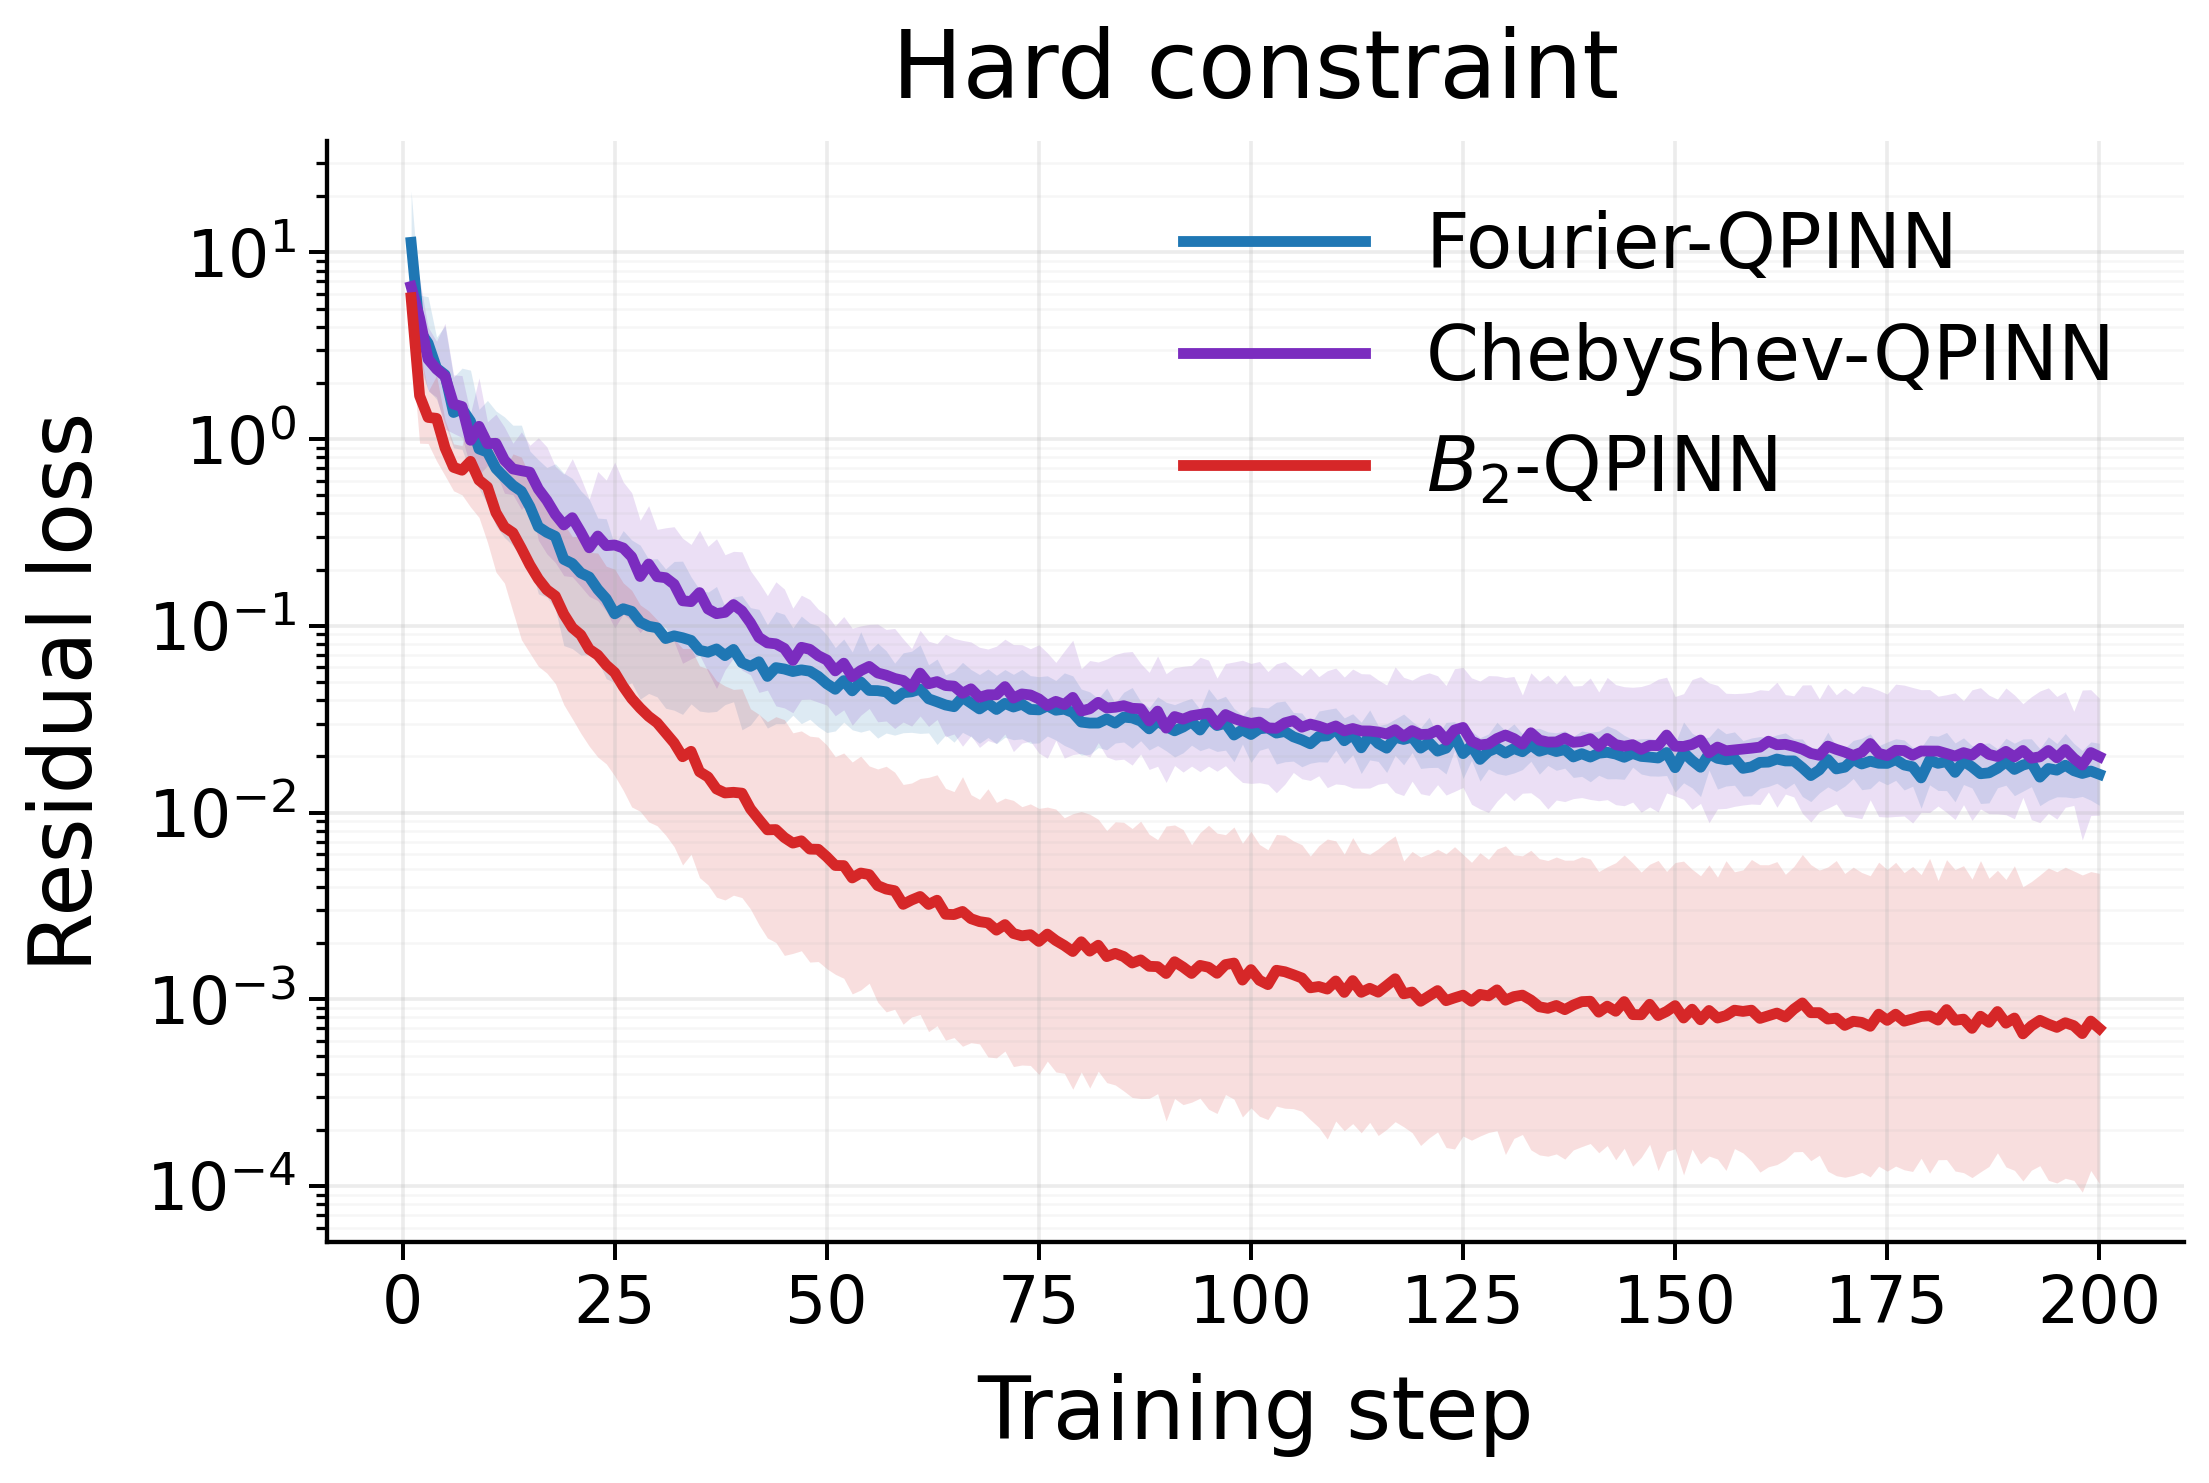

In [10]:
# Replot the saved hard-constraint residual loss with the same style as train_experiment.
# This cell only reads local .npz data; it does not retrain anything.
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

REQUIRED_SLUGS = ["ordinary", "cheb", "b2"]
REQUIRED_KEYS = [f"hard_{slug}_residual_geo_mean" for slug in REQUIRED_SLUGS]
PREFERRED_DATA_PATH = Path(
    r"D:\Projects\quantum-fourier-expressivity\Paper_work\MSQE\figures\random_shift_qfm_cheb_b2_hard\random_shift_qfm_cheb_b2_hard_data.npz"
)

def candidate_npz_paths():
    cwd = Path.cwd().resolve()
    paths = [
        PREFERRED_DATA_PATH,
        PREFERRED_DATA_PATH.with_name("random_shift_qpinn_data.npz"),
    ]
    roots = []
    for base in [cwd, *cwd.parents]:
        roots.extend([
            base / "Paper_work" / "MSQE" / "figures",
            base / "MSQE" / "figures",
            base,
        ])
        if base.name == "quantum-fourier-expressivity":
            break
    seen_roots = set()
    for root in roots:
        root = root.resolve()
        if root in seen_roots or not root.exists() or not root.is_dir():
            continue
        seen_roots.add(root)
        paths.extend(root.rglob("random_shift_qfm_cheb_b2_hard_data.npz"))
        paths.extend(root.rglob("random_shift_qpinn_data.npz"))
        paths.extend(root.rglob("*.npz"))
    seen_paths = set()
    unique_paths = []
    for path in paths:
        path = path.resolve()
        if path not in seen_paths and path.exists() and path.suffix == ".npz":
            seen_paths.add(path)
            unique_paths.append(path)
    return unique_paths

def valid_run_count(data):
    counts = []
    for slug in REQUIRED_SLUGS:
        key = f"hard_{slug}_residual_runs"
        if key in data.files:
            runs = np.asarray(data[key])
            counts.append(runs.shape[0] if runs.ndim >= 2 else 1)
    return min(counts) if counts else 0

def load_three_model_data():
    accepted = []
    rejected = []
    for path in candidate_npz_paths():
        try:
            data = np.load(path, allow_pickle=True)
        except Exception as exc:
            rejected.append(f"{path}: cannot load ({exc})")
            continue
        missing = [key for key in REQUIRED_KEYS if key not in data.files]
        if missing:
            data.close()
            rejected.append(f"{path}: missing {missing}")
            continue
        canonical_score = int(path.name == "random_shift_qfm_cheb_b2_hard_data.npz")
        accepted.append((valid_run_count(data), canonical_score, path.stat().st_mtime, path, data))
    if accepted:
        accepted.sort(key=lambda item: (item[0], item[1], item[2]), reverse=True)
        for _, _, _, _, stale_data in accepted[1:]:
            stale_data.close()
        _, _, _, path, data = accepted[0]
        return path, data
    raise FileNotFoundError(
        "Could not find a saved .npz containing all three residual curves: "
        + ", ".join(REQUIRED_KEYS)
        + "\nChecked/rejected files:\n"
        + "\n".join(rejected[:30])
    )

def scalar_from_npz(data, key, default=None):
    if key not in data.files:
        return default
    value = np.asarray(data[key])
    return value.item() if value.shape == () else value

DATA_PATH, data = load_three_model_data()
steps = np.asarray(data["steps"], dtype=float)
model_slugs = [str(value) for value in data.get("model_slugs", np.asarray(REQUIRED_SLUGS, dtype=str))]
display_labels = [
    str(value)
    for value in data.get(
        "display_labels",
        np.asarray(["Fourier-QPINN", "Chebyshev-QPINN", r"$B_2$-QPINN"], dtype=str),
    )
]
label_by_slug = dict(zip(model_slugs, display_labels))
label_by_slug.update({
    "ordinary": label_by_slug.get("ordinary", "Fourier-QPINN"),
    "cheb": label_by_slug.get("cheb", "Chebyshev-QPINN"),
    "b2": label_by_slug.get("b2", r"$B_2$-QPINN"),
})
color_by_slug = {"ordinary": "#1f77b4", "cheb": "#7b2cbf", "b2": "#d62728"}
run_counts = {}

fig, ax = plt.subplots(figsize=(8.6, 5.8), dpi=220)
for slug in REQUIRED_SLUGS:
    prefix = f"hard_{slug}"
    mean = np.asarray(data[f"{prefix}_residual_geo_mean"], dtype=float)
    lower = np.asarray(data.get(f"{prefix}_residual_geo_lower", mean), dtype=float)
    upper = np.asarray(data.get(f"{prefix}_residual_geo_upper", mean), dtype=float)
    runs = np.asarray(data.get(f"{prefix}_residual_runs", mean[None, :]), dtype=float)
    if runs.ndim == 1:
        runs = runs[None, :]
    run_counts[slug] = runs.shape
    x = steps[: len(mean)]
    color = color_by_slug[slug]
    ax.semilogy(
        x,
        mean,
        label=label_by_slug[slug],
        color=color,
        linewidth=3.0,
    )
    if runs.shape[0] > 1:
        ax.fill_between(
            x,
            lower,
            upper,
            color=color,
            alpha=0.15,
            linewidth=0,
        )
ax.set_title("Hard constraint", fontsize=26, pad=12)
ax.set_xlabel("Training step", fontsize=24, labelpad=10)
ax.set_ylabel("Residual loss", fontsize=24, labelpad=10)
ax.tick_params(axis="both", which="major", labelsize=18, width=1.1, length=5)
ax.tick_params(axis="both", which="minor", width=0.9, length=3)
ax.grid(True, which="major", alpha=0.24, linewidth=1.0)
ax.grid(True, which="minor", alpha=0.10, linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)
ax.legend(frameon=False, loc="best", fontsize=21, handlelength=2.4)
fig.tight_layout()

REPLOT_PATH = DATA_PATH.with_name("random_shift_qfm_cheb_b2_hard_residual_loss_replot.png")
fig.savefig(REPLOT_PATH, dpi=260, bbox_inches="tight")
plt.close(fig)
print(f"loaded data: {DATA_PATH}")
print(f"requested_runs: {scalar_from_npz(data, 'requested_runs', scalar_from_npz(data, 'n_runs', 'unknown'))}")
print(f"completed_runs metadata: {scalar_from_npz(data, 'completed_runs', scalar_from_npz(data, 'n_runs', 'unknown'))}")
print(f"actual residual run arrays: {run_counts}")
print(f"saved figure: {REPLOT_PATH}")
display(Image(filename=str(REPLOT_PATH)))
data.close()
